# Propagation of Sinus-Gordon Solitons

Program propagates soliton solutions of the Sinus-Gordon equation. Both analytical solutions and a direct finite-difference solution of the PDE are provided.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Functions

In [2]:
# Analytical solution of a kink soliton in the Sinus-Gordon equation
def SGSoliton1(x, t, v, c, NG):
    arg = (x - v*t)/np.sqrt(1-(v/c)**2)
    arg = np.clip(arg, -700, 700)
    return 4*np.arctan(np.exp(arg))
    
# Analytical solution of an anti-kink soliton in the Sinus-Gordon equation
def SGSoliton2(x, t, v, c, NG):
    arg = -(x - v*t)/np.sqrt(1-(v/c)**2)
    arg = np.clip(arg, -700, 700)
    return 4*np.arctan(np.exp(arg))

## Parameters

In [3]:
L = 80                       # Length of the spatial grid

NG = 801                     # Number of spatial grid points
dx = L/(NG-1)                # Distance between two grid points
x = -L/4 + np.arange(NG)*dx  

Tmax = 20.                   # Maximum time
NT = 100001                  # Number of time steps
dt = Tmax/(NT-1)             # Time step
t = np.arange(NT)*dt         # Time grid

# Numerical solution for soliton type 1 (kink)

## Prepare grid

In [4]:
y1 = np.zeros((NT, NG))

## Initial conditions

In [5]:
# Initial condition: soliton with velocity v and maximal velocity c
c = 10.
v = 2.
y1[0, :] = SGSoliton1(x, 0, v, c, NG)

# Second time step required for symmetric discrete derivative form
# Soliton has advanced by dt with velocity c
y1[1, :] = SGSoliton1(x, dt, v, c, NG)

## Boundaries

In [6]:
# Set boundaries to expected soliton values
Soliton10 = SGSoliton1(x, 0, v, c, NG)
y1[:, 0] = Soliton10[0]
y1[:, 1] = Soliton10[1]
y1[:, -2] = Soliton10[-2]
y1[:, -1] = Soliton10[-1]

## Solve the PDE using Finite Difference Method

In [7]:
# Solve PDE using finite-difference method
for j in range(2, NT):

    yx2 = y1[j-1, 2:-2] + y1[j-1, 0:-4] - 2*y1[j-1, 1:-3]
    
    y1[j, 1:-1] = 2*y1[j-1, 1:-1] - y1[j-2, 1:-1] + c**2 * dt**2 * (
        (y1[j-1, 2:] + y1[j-1, 0:-2] - 2*y1[j-1, 1:-1]) / dx**2 - np.sin(y1[j-1, 1:-1]))

# Numerical solution for soliton type 2 (anti-kink)

## Prepare grid

In [8]:
# Prepare grid
y2 = np.zeros((NT, NG))

## Initial conditions

In [9]:
# Initial condition: soliton with velocity v and maximal velocity c
c = 10.
v = 2.
y2[0, :] = SGSoliton2(x, 0, v, c, NG)

# Second time step required for symmetric discrete derivative form
# Soliton has advanced by dt with velocity c
y2[1, :] = SGSoliton2(x, dt, v, c, NG)

## Boundaries

In [10]:
# Set boundaries to expected soliton values
Soliton20 = SGSoliton2(x, 0, v, c, NG)
y2[:, 0] = Soliton20[0]
y2[:, 1] = Soliton20[1]
y2[:, -2] = Soliton20[-2]
y2[:, -1] = Soliton20[-1]

## Solve the PDE using Finite Difference Method

In [11]:
# Solve PDE using finite-difference method
for j in range(2, NT):
    
    yx2 = y2[j-1, 2:-2] + y2[j-1, 0:-4] - 2*y2[j-1, 1:-3]

    y2[j, 1:-1] = 2*y2[j-1, 1:-1] - y2[j-2, 1:-1] + c**2 * dt**2 * (
    (y2[j-1, 2:] + y2[j-1, 0:-2] - 2*y2[j-1, 1:-1]) / dx**2 - np.sin(y2[j-1, 1:-1]))

## Visualization of analytical solutions for different parameters

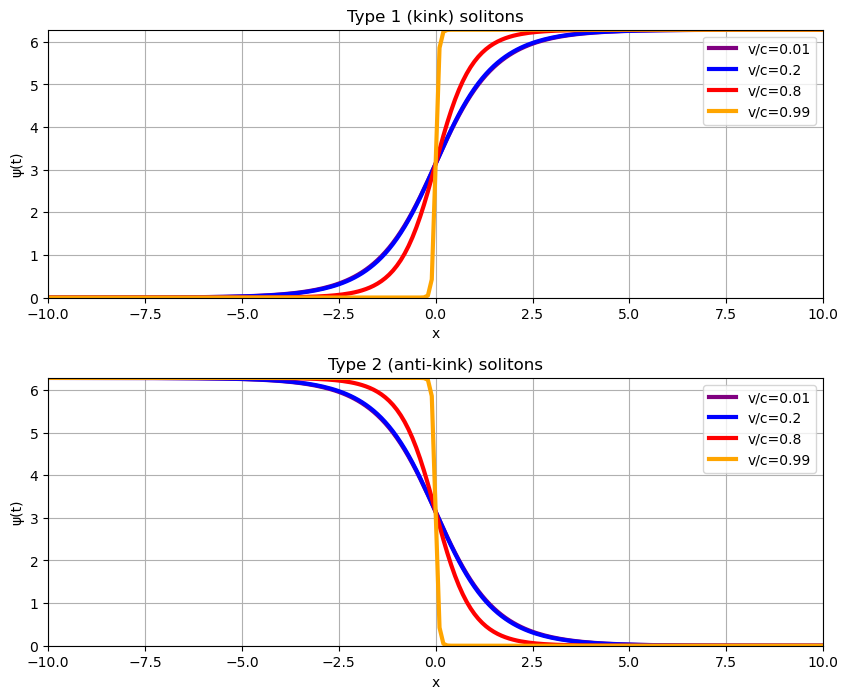

In [12]:
Colors = ['green','purple','blue','red','orange']

plt.figure(figsize=(10,8))

# Type 1 (kink)
plt.subplot(2,1,1)
for idx,vx in enumerate([0.01, 0.2, 0.8, 0.999]):
    plt.plot(x, SGSoliton1(x,0,vx,1,NG), linewidth=3, color=Colors[idx+1])
plt.grid(True)
plt.axis([-10,10,0,2*np.pi])
plt.xlabel('x')
plt.ylabel('ψ(t)')
plt.legend(['v/c=0.01','v/c=0.2','v/c=0.8','v/c=0.99'])
plt.title('Type 1 (kink) solitons')

# Type 2 (anti-kink)
plt.subplot(2,1,2)
for idx,vx in enumerate([0.01, 0.2, 0.8, 0.999]):
    plt.plot(x, SGSoliton2(x,0,vx,1,NG), linewidth=3, color=Colors[idx+1])
plt.grid(True)
plt.axis([-10,10,0,2*np.pi])
plt.xlabel('x')
plt.ylabel('ψ(t)')
plt.legend(['v/c=0.01','v/c=0.2','v/c=0.8','v/c=0.99'])
plt.title('Type 2 (anti-kink) solitons')

plt.subplots_adjust(hspace=0.3)

plt.show()

## Visualization of numerical solutions (moving solitons)

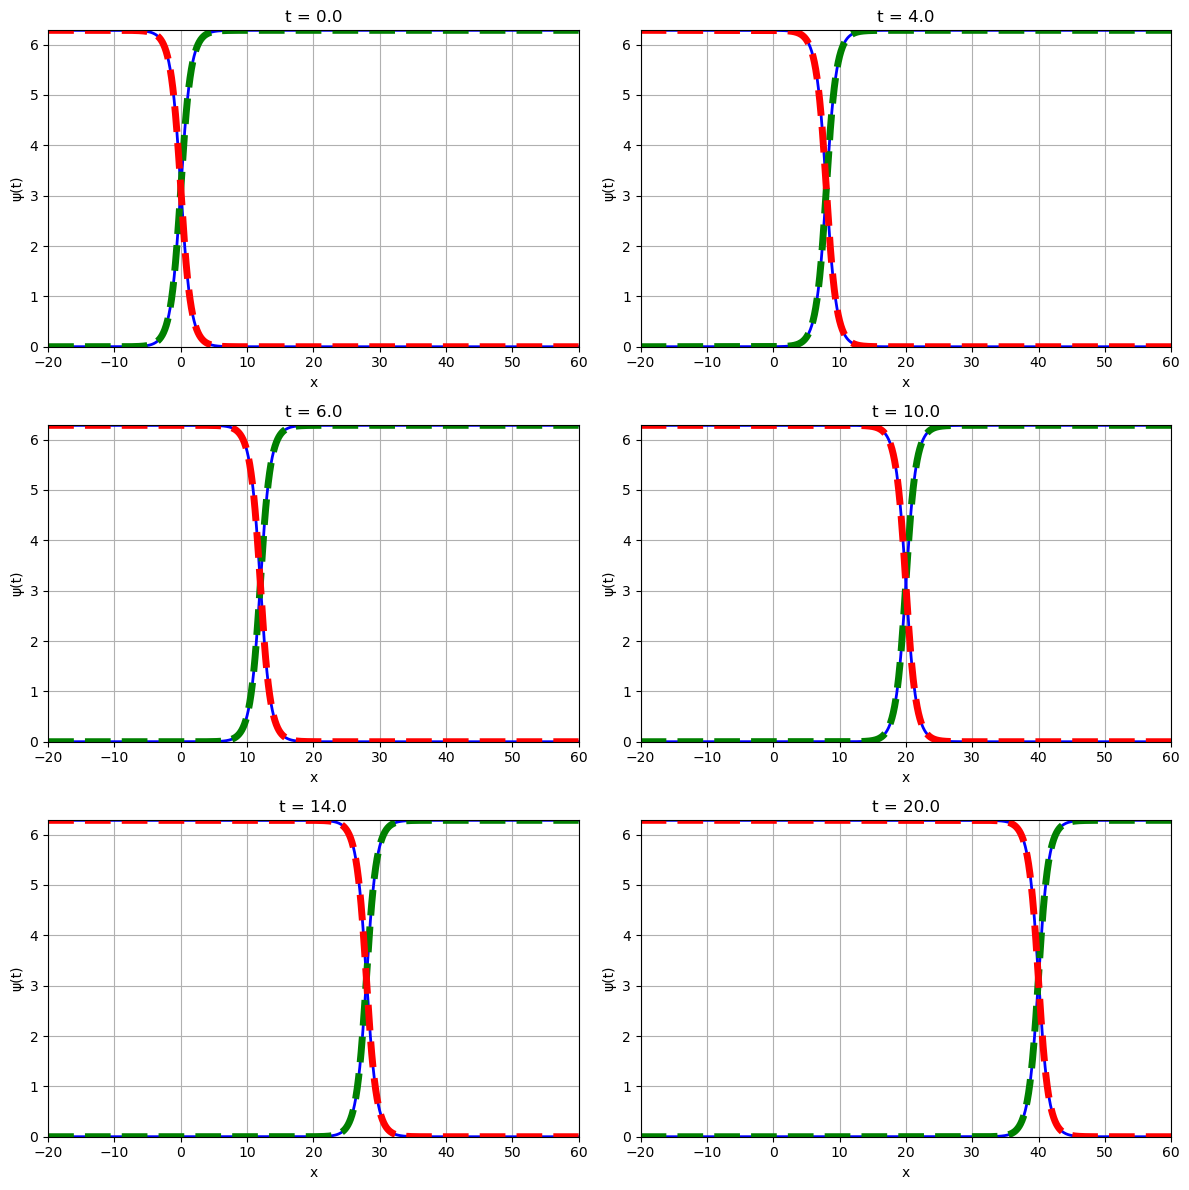

In [13]:
k = [1, 20000, 30000, 50000, 70000, 100001]

plt.figure(figsize=(12,12))

for idx,i in enumerate(k):
    plt.subplot(3,2,idx+1)
    plt.plot(x, SGSoliton1(x, dt*(i-1), v, c, NG), linewidth=2, color=Colors[2])
    plt.plot(x, SGSoliton2(x, dt*(i-1), v, c, NG), linewidth=2, color=Colors[2])
    plt.plot(x, y1[i-1, :], linewidth=5, color=Colors[0], linestyle='--')
    plt.plot(x, y2[i-1, :], linewidth=5, color=Colors[3], linestyle='--')
    plt.grid(True)
    plt.axis([np.min(x), np.max(x), 0, 2*np.pi])
    plt.xlabel('x')
    plt.ylabel('ψ(t)')
    plt.title(f't = {t[i-1]:.1f}')
plt.tight_layout()
plt.show()